# Data Processing

## Data cleaning

In [1]:
import pandas as pd
import numpy as np
import openpyxl

In [80]:
df = pd.read_excel("Online Retail.xlsx")
#Display the first 5 rows of the data.
print(df.shape)
df.head()

(541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [81]:
# 数据类型和缺失值
df.info()

# 描述统计
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


### processing missing values

In [82]:
#Filter out the rows that do not have a customer ID, and retain only the data with valid customer IDs.
df = df[~df["CustomerID"].isna()].copy()
df["CustomerID"] = df["CustomerID"].astype(int).astype(str)

In [83]:
# return orders
df["IsReturn"] = df["Quantity"] < 0

In [84]:
# only save normal purchase order
df = df[
    (df["Quantity"] > 0) &
    (df["UnitPrice"] > 0)
].copy()

In [85]:
# time field
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

# time features-data-month-week
df["Date"] = df["InvoiceDate"].dt.date
df["YearMonth"] = df["InvoiceDate"].dt.to_period("M")
df["Week"] = df["InvoiceDate"].dt.isocalendar().week
df["DayOfWeek"] = df["InvoiceDate"].dt.dayofweek
df["IsWeekend"] = df["DayOfWeek"].isin([5, 6]).astype(int)

df["Hour"] = df["InvoiceDate"].dt.hour

## Reform table

### Customer level

In [86]:
# Observation window end time (usually the maximum date)
snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

print("Snapshot date:", snapshot_date)
# compute revenue
df['Revenue']=df['Quantity']*df['UnitPrice']

Snapshot date: 2011-12-10 12:50:00


In [87]:
# ================================
# RFM Calculate
# ================================

rfm = df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,  # Recency
    "InvoiceNo": "nunique",                                  # Frequency（订单数）
    "Revenue": "sum"                                         # Monetary（总消费）
}).reset_index()

rfm.columns = ["CustomerID", "Recency", "Frequency", "Monetary"]

In [88]:
#Life cycle
customer_dates = df.groupby("CustomerID").agg({
    "InvoiceDate": ["min", "max"]
})

customer_dates.columns = ["FirstPurchase", "LastPurchase"]
customer_dates = customer_dates.reset_index()

customer_dates["Tenure"] = (
    customer_dates["LastPurchase"] - customer_dates["FirstPurchase"]
).dt.days


In [89]:
#average order value
order_revenue = df.groupby(["CustomerID", "InvoiceNo"])["Revenue"].sum().reset_index()

aov = order_revenue.groupby("CustomerID")["Revenue"].mean().reset_index()
aov.columns = ["CustomerID", "AvgOrderValue"]

In [90]:
#Calculate the average number of items purchased per customer order.
basket = df.groupby(["CustomerID", "InvoiceNo"])["Quantity"].sum().reset_index()

basket_size = basket.groupby("CustomerID")["Quantity"].mean().reset_index()
basket_size.columns = ["CustomerID", "AvgBasketSize"]


In [91]:
# product diversity
product_div = df.groupby("CustomerID")["StockCode"].nunique().reset_index()
product_div.columns = ["CustomerID", "ProductDiversity"]

In [92]:
# The average number of days between 2 purchases for each customerid
df_sorted = df.sort_values(["CustomerID", "InvoiceDate"])

df_sorted["PrevPurchase"] = df_sorted.groupby("CustomerID")["InvoiceDate"].shift(1)

df_sorted["PurchaseInterval"] = (
    df_sorted["InvoiceDate"] - df_sorted["PrevPurchase"]
).dt.days

purchase_interval = df_sorted.groupby("CustomerID")["PurchaseInterval"].agg(["mean", "std"]).reset_index()
purchase_interval.columns = ["CustomerID", "PurchaseIntervalMean", "PurchaseIntervalStd"]

In [93]:
weekend_ratio = df.groupby("CustomerID")["IsWeekend"].mean().reset_index()
weekend_ratio.columns = ["CustomerID", "WeekendPurchaseRatio"]

In [94]:
active_months = df.groupby("CustomerID")["YearMonth"].nunique().reset_index()
active_months.columns = ["CustomerID", "ActiveMonths"]

In [95]:
country = df.groupby("CustomerID")["Country"].first().reset_index()

In [96]:
customer_df = rfm.merge(customer_dates, on="CustomerID")
customer_df = customer_df.merge(aov, on="CustomerID")
customer_df = customer_df.merge(basket_size, on="CustomerID")
customer_df = customer_df.merge(product_div, on="CustomerID")
customer_df = customer_df.merge(purchase_interval, on="CustomerID")
customer_df = customer_df.merge(weekend_ratio, on="CustomerID")
customer_df = customer_df.merge(active_months, on="CustomerID")
customer_df = customer_df.merge(country, on="CustomerID")

In [97]:
# process null value : new customer or only buy once 
customer_df = customer_df.fillna(0)

In [98]:
print(customer_df.shape)
customer_df.head()
customer_df.describe()

(4338, 15)


,Recency,Frequency,Monetary,FirstPurchase,LastPurchase,Tenure,AvgOrderValue,AvgBasketSize,ProductDiversity,PurchaseIntervalMean,PurchaseIntervalStd,WeekendPurchaseRatio,ActiveMonths
count,4338.000000,4338.000000,4338.000000,4338,4338,4338.000000,4338.000000,4338.000000,4338.000000,4338.000000,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2054.266460,2011-04-30 17:06:50.857538048,2011-09-08 11:38:59.045643008,130.448594,419.166289,253.478280,61.501153,3.205654,11.256864,0.132285,3.009221
min,1.000000,1.000000,3.750000,2010-12-01 08:26:00,2010-12-01 09:53:00,0.000000,3.450000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,18.000000,1.000000,307.415000,2011-01-17 11:13:15,2011-07-20 19:18:00,0.000000,178.625000,93.000000,16.000000,0.000000,0.000000,0.000000,1.000000
50%,51.000000,2.000000,674.485000,2011-04-05 09:52:30,2011-10-20 10:40:30,92.500000,293.900000,161.750000,35.000000,1.060511,6.814170,0.000000,2.000000
75%,142.000000,5.000000,1661.740000,2011-08-19 10:11:30,2011-11-22 11:05:45,251.750000,430.113750,272.000000,77.000000,2.920000,15.797229,0.088235,4.000000
max,374.000000,209.000000,280206.020000,2011-12-09 12:16:00,2011-12-09 12:50:00,373.000000,84236.250000,74215.000000,1787.000000,309.000000,210.155498,1.000000,13.000000
std,100.014169,7.697998,8989.230441,NaN,NaN,132.039554,1796.537944,1312.905974,85.366768,10.790683,15.887990,0.279962,2.627853


### Order level

### Aggregated table

# Customer segmentation

## Quantile RFM segmentation

In [99]:
rfm_df = customer_df.copy()
rfm_df.head()

,CustomerID,Recency,Frequency,Monetary,FirstPurchase,LastPurchase,Tenure,AvgOrderValue,AvgBasketSize,ProductDiversity,PurchaseIntervalMean,PurchaseIntervalStd,WeekendPurchaseRatio,ActiveMonths,Country
0,12346,326,1,77183.60,2011-01-18 10:01:00,2011-01-18 10:01:00,0,77183.600000,74215.000000,1,0.0,0.000000,0.000000,1,United Kingdom
1,12347,2,7,4310.00,2010-12-07 14:57:00,2011-12-07 15:52:00,365,615.714286,351.142857,103,2.0,11.260551,0.000000,7,Iceland
2,12348,75,4,1797.24,2010-12-16 19:09:00,2011-09-25 13:13:00,282,449.310000,585.250000,22,9.4,34.088728,0.096774,4,Finland
3,12349,19,1,1757.55,2011-11-21 09:51:00,2011-11-21 09:51:00,0,1757.550000,631.000000,73,0.0,0.000000,0.000000,1,Italy
4,12350,310,1,334.40,2011-02-02 16:01:00,2011-02-02 16:01:00,0,334.400000,197.000000,17,0.0,0.000000,0.000000,1,Norway


In [100]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [101]:
rfm_compare = rfm_df[["CustomerID", "Recency", "Frequency", "Monetary"]].copy()
rfm_compare = rfm_compare.replace([np.inf, -np.inf], np.nan).dropna()

print(rfm_compare.shape)
rfm_compare.head()

(4338, 4)


,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40


In [102]:
rfm_compare.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2054.266460
std,100.014169,7.697998,8989.230441
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,307.415000
50%,51.000000,2.000000,674.485000
75%,142.000000,5.000000,1661.740000
max,374.000000,209.000000,280206.020000


In [103]:
# Recency 越小越好，所以分数反向
rfm_compare["R_score"] = pd.qcut(
    rfm_compare["Recency"],
    5,
    labels=[5, 4, 3, 2, 1],
    duplicates="drop"
)

# Frequency 和 Monetary 越大越好
rfm_compare["F_score"] = pd.qcut(
    rfm_compare["Frequency"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5],
    duplicates="drop"
)

rfm_compare["M_score"] = pd.qcut(
    rfm_compare["Monetary"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5],
    duplicates="drop"
)

rfm_compare["R_score"] = rfm_compare["R_score"].astype(int)
rfm_compare["F_score"] = rfm_compare["F_score"].astype(int)
rfm_compare["M_score"] = rfm_compare["M_score"].astype(int)

rfm_compare["RFM_Total"] = rfm_compare[["R_score", "F_score", "M_score"]].sum(axis=1)
rfm_compare["RFM_Code"] = (
    rfm_compare["R_score"].astype(str) +
    rfm_compare["F_score"].astype(str) +
    rfm_compare["M_score"].astype(str)
)

In [104]:
def quantile_segment(row):
    r, f, m = row["R_score"], row["F_score"], row["M_score"]
    
    if r >= 4 and f >= 4 and m >= 4:
        return "Champions"
    elif r >= 3 and f >= 4 and m >= 3:
        return "Loyal Customers"
    elif r >= 4 and f <= 2:
        return "New Customers"
    elif r <= 2 and f >= 3 and m >= 3:
        return "At Risk"
    elif r <= 2 and f <= 2 and m <= 2:
        return "Hibernating"
    else:
        return "Potential Loyalists"

rfm_compare["Quantile_Segment"] = rfm_compare.apply(quantile_segment, axis=1)

rfm_compare["Quantile_Segment"].value_counts()

Quantile_Segment
Potential Loyalists    1332
Champions               962
Hibernating             824
At Risk                 454
Loyal Customers         447
New Customers           319
Name: count, dtype: int64

## Kmeans segmentation

In [105]:
rfm_compare["Recency_log"] = np.log1p(rfm_compare["Recency"])
rfm_compare["Frequency_log"] = np.log1p(rfm_compare["Frequency"])
rfm_compare["Monetary_log"] = np.log1p(rfm_compare["Monetary"])

# standardize
features = rfm_compare[["Recency_log", "Frequency_log", "Monetary_log"]]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

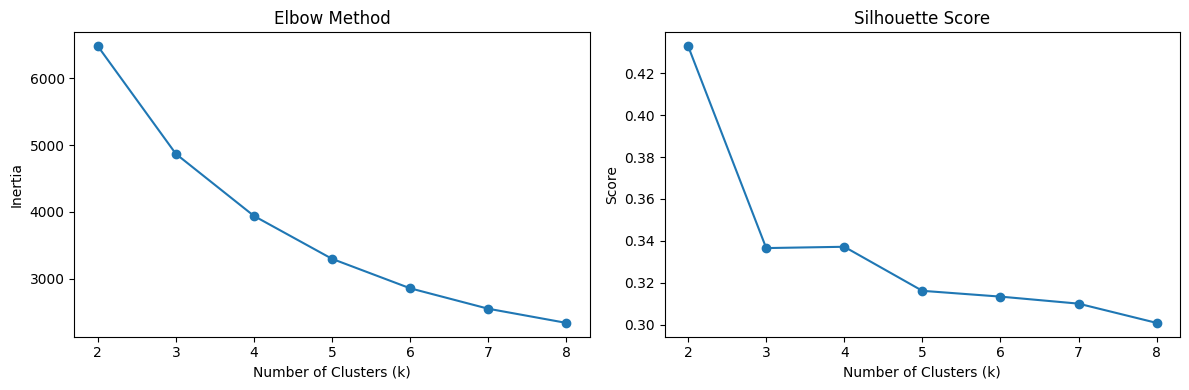

In [106]:
#Silhouette Score and elbow method choose K 
inertia = []
sil_scores = []
k_range = range(2, 9)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    inertia.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(list(k_range), inertia, marker="o")
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")

plt.subplot(1, 2, 2)
plt.plot(list(k_range), sil_scores, marker="o")
plt.title("Silhouette Score")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Score")

plt.tight_layout()
plt.show()

In [107]:
k = 5  # easy to explain 
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
rfm_compare["KMeans_Cluster"] = kmeans.fit_predict(X_scaled)

In [108]:
# mean of each cluster
kmeans_summary = rfm_compare.groupby("KMeans_Cluster")[["Recency", "Frequency", "Monetary"]].mean().round(2)
kmeans_summary

,Recency,Frequency,Monetary
KMeans_Cluster,,,
0,27.99,1.61,389.04
1,18.55,5.80,2168.93
2,211.15,1.21,277.20
3,12.19,20.63,13780.08
4,104.14,3.13,1455.97


In [109]:
cluster_profile = rfm_compare.groupby("KMeans_Cluster")[["Recency_log", "Frequency_log", "Monetary_log"]].mean().round(2)
cluster_profile

,Recency_log,Frequency_log,Monetary_log
KMeans_Cluster,,,
0,3.14,0.93,5.79
1,2.64,1.86,7.50
2,5.24,0.78,5.43
3,2.07,2.90,8.93
4,4.48,1.36,6.99


In [110]:
cluster_name_map = {
    3: "Champions",
    1: "Loyal Customers",
    4: "At Risk",
    0: "New / Low Value",
    2: "Hibernating"
}

rfm_compare["KMeans_Label"] = rfm_compare["KMeans_Cluster"].map(cluster_name_map)

In [111]:
rfm_compare["KMeans_Label"].value_counts()

KMeans_Label
Hibernating        1185
At Risk            1015
Loyal Customers     944
New / Low Value     851
Champions           343
Name: count, dtype: int64

In [112]:
kmeans_summary_named = rfm_compare.groupby("KMeans_Label")[["Recency", "Frequency", "Monetary"]].mean().round(2)
kmeans_summary_named

,Recency,Frequency,Monetary
KMeans_Label,,,
At Risk,104.14,3.13,1455.97
Champions,12.19,20.63,13780.08
Hibernating,211.15,1.21,277.20
Loyal Customers,18.55,5.80,2168.93
New / Low Value,27.99,1.61,389.04


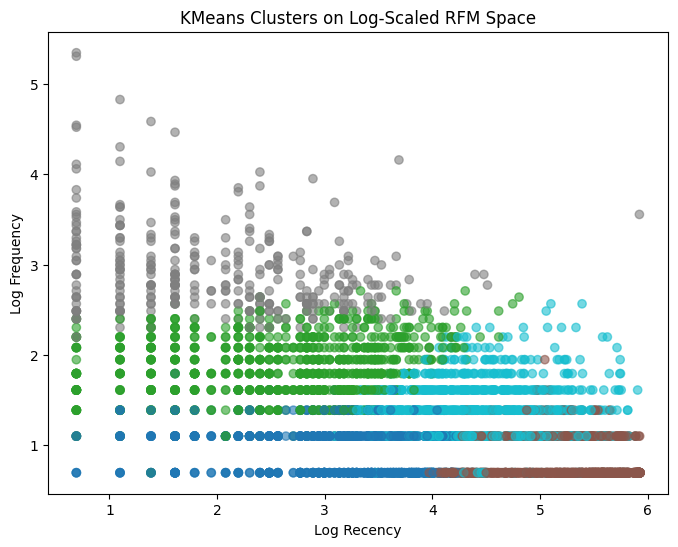

In [113]:
plt.figure(figsize=(8, 6))
plt.scatter(
    rfm_compare["Recency_log"],
    rfm_compare["Frequency_log"],
    c=rfm_compare["KMeans_Cluster"],
    cmap="tab10",
    alpha=0.6
)
plt.xlabel("Log Recency")
plt.ylabel("Log Frequency")
plt.title("KMeans Clusters on Log-Scaled RFM Space")
plt.show()

## Comparison

In [114]:
pd.crosstab(
    rfm_compare["Quantile_Segment"],
    rfm_compare["KMeans_Label"],
    margins=True
)

KMeans_Label,At Risk,Champions,Hibernating,Loyal Customers,New / Low Value,All
Quantile_Segment,,,,,,
At Risk,430,4,12,8,0,454
Champions,14,325,0,623,0,962
Hibernating,2,0,822,0,0,824
Loyal Customers,189,13,0,223,22,447
New Customers,7,0,0,12,300,319
Potential Loyalists,373,1,351,78,529,1332
All,1015,343,1185,944,851,4338


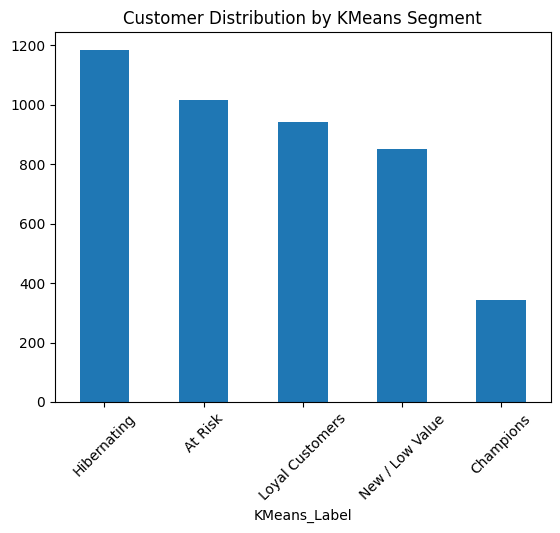

In [115]:
rfm_compare["KMeans_Label"].value_counts().plot(kind="bar")
plt.title("Customer Distribution by KMeans Segment")
plt.xticks(rotation=45)
plt.show()

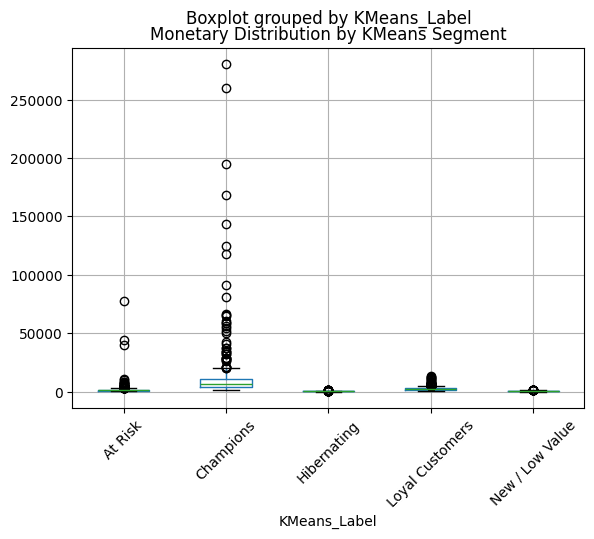

In [116]:
rfm_compare.boxplot(column="Monetary", by="KMeans_Label", rot=45)
plt.title("Monetary Distribution by KMeans Segment")
plt.show()

# CLV

## Preparation

In [117]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from lifetimes.utils import summary_data_from_transaction_data
from lifetimes import BetaGeoFitter, GammaGammaFitter

In [118]:
df_clean = df.copy()

In [119]:
# ensure key string exists
required_cols = ["CustomerID", "InvoiceDate", "Revenue"]
print(df_clean[required_cols].head())

# Reconfirm the type
df["InvoiceDate"] = pd.to_datetime(df_clean["InvoiceDate"])
df["CustomerID"] = df_clean["CustomerID"].astype(str)

  CustomerID         InvoiceDate  Revenue
0      17850 2010-12-01 08:26:00    15.30
1      17850 2010-12-01 08:26:00    20.34
2      17850 2010-12-01 08:26:00    22.00
3      17850 2010-12-01 08:26:00    20.34
4      17850 2010-12-01 08:26:00    20.34


In [120]:
# build BTYD table
snapshot_date = df_clean["InvoiceDate"].max()

clv_summary = summary_data_from_transaction_data(
    transactions=df_clean,
    customer_id_col="CustomerID",
    datetime_col="InvoiceDate",
    monetary_value_col="Revenue",
    observation_period_end=snapshot_date,
    freq="D"
)

clv_summary.head()

,frequency,recency,T,monetary_value
CustomerID,,,,
12346,0.0,0.0,325.0,0.000000
12347,6.0,365.0,367.0,599.701667
12348,3.0,283.0,358.0,301.480000
12349,0.0,0.0,18.0,0.000000
12350,0.0,0.0,310.0,0.000000


In [121]:
clv_summary.describe()##check distribution

,frequency,recency,T,monetary_value
count,4338.000000,4338.000000,4338.000000,4338.000000
mean,2.864223,130.771554,222.831028,307.028848
std,5.949000,132.210509,117.854570,2612.749850
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,112.000000,0.000000
50%,1.000000,93.000000,248.000000,177.064773
75%,3.000000,252.000000,326.000000,360.162500
max,131.000000,373.000000,373.000000,168469.600000


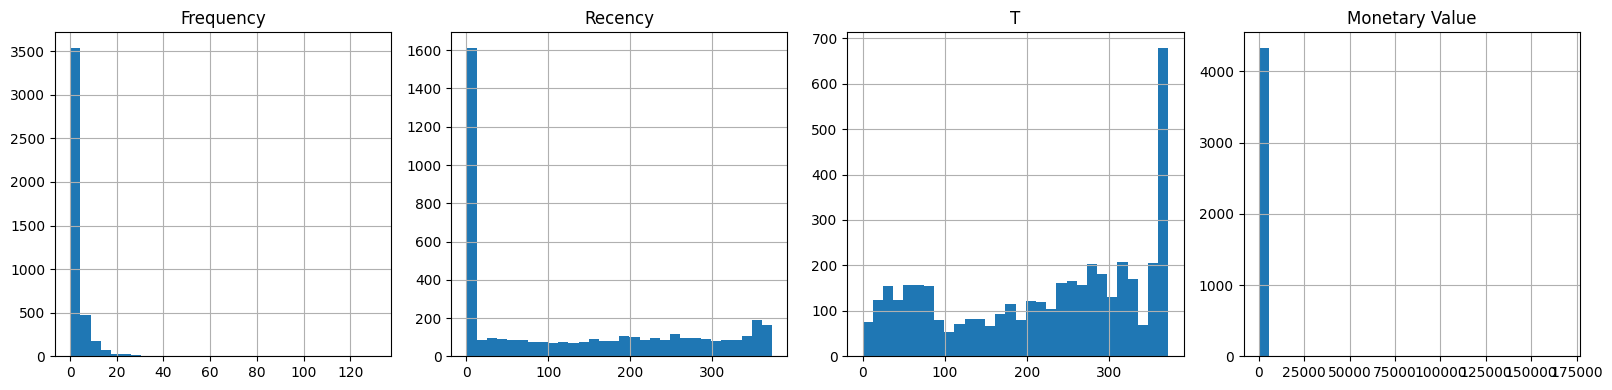

In [122]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
clv_summary["frequency"].hist(bins=30, ax=axes[0])
axes[0].set_title("Frequency")

clv_summary["recency"].hist(bins=30, ax=axes[1])
axes[1].set_title("Recency")

clv_summary["T"].hist(bins=30, ax=axes[2])
axes[2].set_title("T")

clv_summary["monetary_value"].hist(bins=30, ax=axes[3])
axes[3].set_title("Monetary Value")

plt.tight_layout()
plt.show()

In [123]:
# filter out data suitable for GG
clv_model_data = clv_summary[
    (clv_summary["frequency"] > 0) &
    (clv_summary["monetary_value"] > 0)
].copy()

print(clv_model_data.shape)
clv_model_data.head()

(2790, 4)


,frequency,recency,T,monetary_value
CustomerID,,,,
12347,6.0,365.0,367.0,599.701667
12348,3.0,283.0,358.0,301.480000
12352,6.0,260.0,296.0,368.256667
12356,2.0,303.0,325.0,269.905000
12358,1.0,149.0,150.0,683.200000


## Fitting BG/NBD: Predicting Future Purchase Frequency

In [124]:
bgf = BetaGeoFitter(penalizer_coef=0.01)

bgf.fit(
    clv_model_data["frequency"],
    clv_model_data["recency"],
    clv_model_data["T"]
)

<lifetimes.BetaGeoFitter: fitted with 2790 subjects, a: 0.01, alpha: 89.90, b: 0.13, r: 1.60>

In [125]:
# predict the number of transaction in 90 days
clv_model_data["PredictedPurchases_90D"] = bgf.predict(
    90,
    clv_model_data["frequency"],
    clv_model_data["recency"],
    clv_model_data["T"]
)

clv_model_data[["frequency", "recency", "T", "PredictedPurchases_90D"]].head()

,frequency,recency,T,PredictedPurchases_90D
CustomerID,,,,
12347,6.0,365.0,367.0,1.494064
12348,3.0,283.0,358.0,0.917068
12352,6.0,260.0,296.0,1.766309
12356,2.0,303.0,325.0,0.774697
12358,1.0,149.0,150.0,0.927438


## Calculating alive probability

In [126]:
# The "AliveProb" can be compared with these segments.
clv_model_data["AliveProb"] = bgf.conditional_probability_alive(
    clv_model_data["frequency"],
    clv_model_data["recency"],
    clv_model_data["T"]
)

clv_model_data[["PredictedPurchases_90D", "AliveProb"]].head()

,PredictedPurchases_90D,AliveProb
CustomerID,,
12347,1.494064,0.998693
12348,0.917068,0.992973
12352,1.766309,0.997342
12356,0.774697,0.993076
12358,0.927438,0.953344


## Fitting Gamma-Gamma: Predicting average amount per purchase

In [127]:
ggf = GammaGammaFitter(penalizer_coef=0.01)

ggf.fit(
    clv_model_data["frequency"],
    clv_model_data["monetary_value"]
)

<lifetimes.GammaGammaFitter: fitted with 2790 subjects, p: 3.75, q: 0.33, v: 3.64>

In [128]:
# predict future avg profit
clv_model_data["ExpectedAvgProfit"] = ggf.conditional_expected_average_profit(
    clv_model_data["frequency"],
    clv_model_data["monetary_value"]
)

clv_model_data[["monetary_value", "ExpectedAvgProfit"]].head()

,monetary_value,ExpectedAvgProfit
CustomerID,,
12347,599.701667,618.580281
12348,301.480000,321.698923
12352,368.256667,380.090885
12356,269.905000,298.146326
12358,683.200000,834.789440


## Calculating CLV in 3 months and 6 months

In [129]:
clv_model_data["CLV_3M"] = ggf.customer_lifetime_value(
    transaction_prediction_model=bgf,
    frequency=clv_model_data["frequency"],
    recency=clv_model_data["recency"],
    T=clv_model_data["T"],
    monetary_value=clv_model_data["monetary_value"],
    time=3,          # 3个月
    freq="D",
    discount_rate=0.01
)

clv_model_data.head()

,frequency,recency,T,monetary_value,PredictedPurchases_90D,AliveProb,ExpectedAvgProfit,CLV_3M
CustomerID,,,,,,,,
12347,6.0,365.0,367.0,599.701667,1.494064,0.998693,618.580281,906.021007
12348,3.0,283.0,358.0,301.480000,0.917068,0.992973,321.698923,289.217694
12352,6.0,260.0,296.0,368.256667,1.766309,0.997342,380.090885,658.153821
12356,2.0,303.0,325.0,269.905000,0.774697,0.993076,298.146326,226.430772
12358,1.0,149.0,150.0,683.200000,0.927438,0.953344,834.789440,758.994803


In [130]:
clv_model_data["CLV_6M"] = ggf.customer_lifetime_value(
    transaction_prediction_model=bgf,
    frequency=clv_model_data["frequency"],
    recency=clv_model_data["recency"],
    T=clv_model_data["T"],
    monetary_value=clv_model_data["monetary_value"],
    time=6,
    freq="D",
    discount_rate=0.01
)

In [131]:
clv_model_data["CLV_3M"].describe()

count      2790.000000
mean        811.343762
std        3607.865510
min           3.342667
25%         207.126935
50%         398.182582
75%         746.332247
max      151598.628438
Name: CLV_3M, dtype: float64

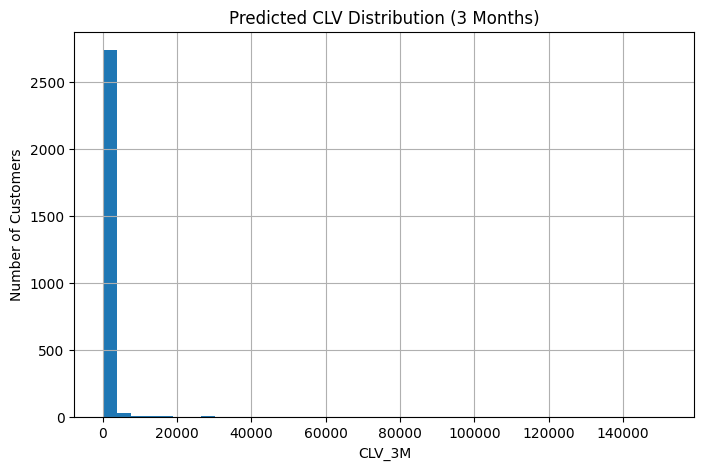

In [132]:
plt.figure(figsize=(8, 5))
clv_model_data["CLV_3M"].hist(bins=40)
plt.title("Predicted CLV Distribution (3 Months)")
plt.xlabel("CLV_3M")
plt.ylabel("Number of Customers")
plt.show()

## CLV merged into segmentations 

In [133]:
clv_model_data_reset = clv_model_data.reset_index()

rfm_clv = rfm_compare.merge(
    clv_model_data_reset[
        ["CustomerID", "PredictedPurchases_90D", "AliveProb", "ExpectedAvgProfit", "CLV_3M", "CLV_6M"]
    ],
    on="CustomerID",
    how="left"
)

rfm_clv.head()

,CustomerID,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Total,RFM_Code,Quantile_Segment,Recency_log,Frequency_log,Monetary_log,KMeans_Cluster,KMeans_Label,PredictedPurchases_90D,AliveProb,ExpectedAvgProfit,CLV_3M,CLV_6M
0,12346,326,1,77183.60,1,1,5,7,115,Potential Loyalists,5.789960,0.693147,11.253955,4,At Risk,NaN,NaN,NaN,NaN,NaN
1,12347,2,7,4310.00,5,5,5,15,555,Champions,1.098612,2.079442,8.368925,1,Loyal Customers,1.494064,0.998693,618.580281,906.021007,1784.142051
2,12348,75,4,1797.24,2,4,4,10,244,At Risk,4.330733,1.609438,7.494564,4,At Risk,0.917068,0.992973,321.698923,289.217694,569.431786
3,12349,19,1,1757.55,4,1,4,9,414,New Customers,2.995732,0.693147,7.472245,0,New / Low Value,NaN,NaN,NaN,NaN,NaN
4,12350,310,1,334.40,1,1,2,4,112,Hibernating,5.739793,0.693147,5.815324,2,Hibernating,NaN,NaN,NaN,NaN,NaN


### Quantile RFM comparison 

In [134]:
quantile_clv_summary = (
    rfm_clv.groupby("Quantile_Segment")[["PredictedPurchases_90D", "AliveProb", "ExpectedAvgProfit", "CLV_3M"]]
    .mean()
    .round(2)
    .sort_values("CLV_3M", ascending=False)
)

quantile_clv_summary

,PredictedPurchases_90D,AliveProb,ExpectedAvgProfit,CLV_3M
Quantile_Segment,,,,
Champions,2.39,1.00,542.97,1415.64
Loyal Customers,1.41,0.99,398.05,556.02
New Customers,1.11,0.94,493.19,550.74
Potential Loyalists,0.94,0.90,609.54,515.19
At Risk,0.90,0.89,535.18,414.48
Hibernating,0.49,0.73,173.91,82.48


### Kmeans comparison

In [135]:
kmeans_clv_summary = (
    rfm_clv.groupby("KMeans_Label")[["PredictedPurchases_90D", "AliveProb", "ExpectedAvgProfit", "CLV_3M"]]
    .mean()
    .round(2)
    .sort_values("CLV_3M", ascending=False)
)

kmeans_clv_summary

,PredictedPurchases_90D,AliveProb,ExpectedAvgProfit,CLV_3M
KMeans_Label,,,,
Champions,3.70,1.00,1351.53,3254.71
Loyal Customers,1.65,0.99,460.16,693.86
At Risk,0.93,0.92,501.12,413.15
New / Low Value,1.10,0.95,247.93,256.37
Hibernating,0.51,0.73,171.46,77.60


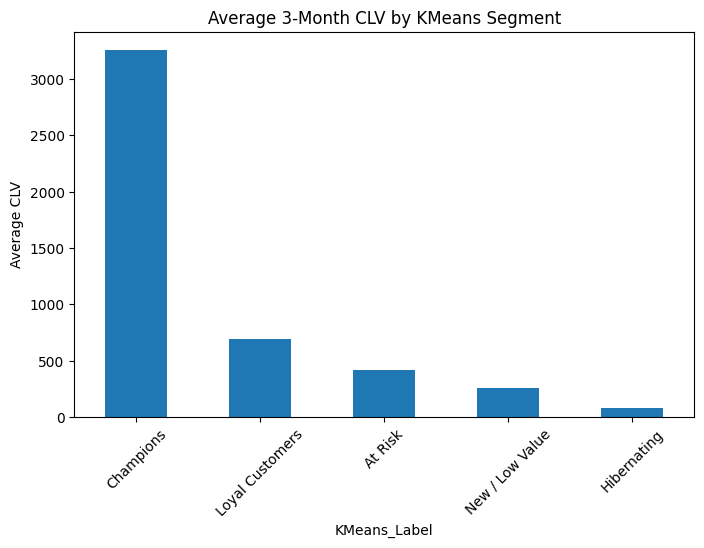

In [136]:
kmeans_clv_summary["CLV_3M"].plot(kind="bar", figsize=(8, 5))
plt.title("Average 3-Month CLV by KMeans Segment")
plt.ylabel("Average CLV")
plt.xticks(rotation=45)
plt.show()

### Countrys 

In [137]:
print(rfm_clv.columns)
print("Country" in rfm_clv.columns)

Index(['CustomerID', 'Recency', 'Frequency', 'Monetary', 'R_score', 'F_score',
       'M_score', 'RFM_Total', 'RFM_Code', 'Quantile_Segment', 'Recency_log',
       'Frequency_log', 'Monetary_log', 'KMeans_Cluster', 'KMeans_Label',
       'PredictedPurchases_90D', 'AliveProb', 'ExpectedAvgProfit', 'CLV_3M',
       'CLV_6M'],
      dtype='object')
False


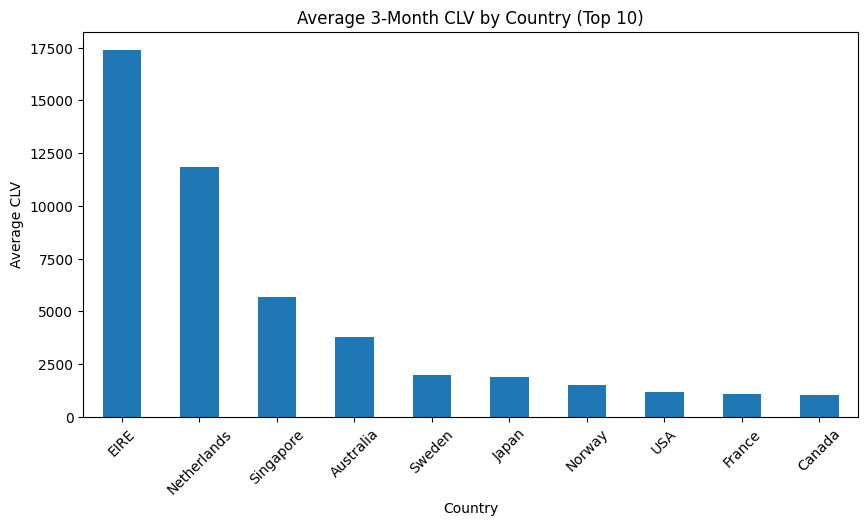

In [138]:
# 如果 rfm_clv 里没有 Country，就补进去
if "Country" not in rfm_clv.columns:
    customer_country = df_clean.groupby("CustomerID")["Country"].first().reset_index()
    rfm_clv = rfm_clv.merge(customer_country, on="CustomerID", how="left")

# 再做 Country × CLV
country_clv = (
    rfm_clv.groupby("Country")["CLV_3M"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

country_clv.plot(kind="bar", figsize=(10, 5))
plt.title("Average 3-Month CLV by Country (Top 10)")
plt.ylabel("Average CLV")
plt.xticks(rotation=45)
plt.show()

In [139]:
clv_model_data["CLV_3M"].describe()

count      2790.000000
mean        811.343762
std        3607.865510
min           3.342667
25%         207.126935
50%         398.182582
75%         746.332247
max      151598.628438
Name: CLV_3M, dtype: float64

### RFM×CLV  : How to allocate resources

In [140]:
rfm_clv["CLV_Group"] = pd.qcut(
    rfm_clv["CLV_3M"],
    2,
    labels=["Low CLV", "High CLV"]
)

rfm_clv["RFM_Group"] = np.where(
    rfm_clv["KMeans_Label"].isin(["Champions", "Loyal Customers"]),
    "High RFM",
    "Low RFM"
)

In [141]:
pd.crosstab(
    rfm_clv["RFM_Group"],
    rfm_clv["CLV_Group"],
    margins=True
)

CLV_Group,Low CLV,High CLV,All
RFM_Group,,,
High RFM,290,995,1285
Low RFM,1105,400,1505
All,1395,1395,2790


In [142]:
#potential customers
potential = rfm_clv[
    (rfm_clv["RFM_Group"] == "Low RFM") &
    (rfm_clv["CLV_Group"] == "High CLV")
]

potential.head()

,CustomerID,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Total,RFM_Code,Quantile_Segment,...,KMeans_Cluster,KMeans_Label,PredictedPurchases_90D,AliveProb,ExpectedAvgProfit,CLV_3M,CLV_6M,Country,CLV_Group,RFM_Group
12,12359,58,4,6372.58,3,4,5,12,345,Loyal Customers,...,4,At Risk,0.976931,0.994086,2064.891594,1977.582644,3893.436660,Cyprus,High CLV,Low RFM
13,12360,52,3,2662.06,3,3,5,11,335,Potential Loyalists,...,4,At Risk,1.103022,0.988457,867.975419,938.569618,1846.976689,Austria,High CLV,Low RFM
20,12370,51,4,3545.69,3,4,5,12,345,Loyal Customers,...,4,At Risk,0.914612,0.994730,693.825695,622.100667,1224.838440,Cyprus,High CLV,Low RFM
21,12371,45,2,1887.96,3,2,4,9,324,Potential Loyalists,...,4,At Risk,1.397012,0.892542,441.972260,605.304434,1189.683497,Switzerland,High CLV,Low RFM
22,12372,72,3,1298.04,3,3,4,10,334,Potential Loyalists,...,4,At Risk,0.828770,0.988223,495.104304,402.258041,791.783565,Denmark,High CLV,Low RFM


In [143]:
# overrated customers
overrated = rfm_clv[
    (rfm_clv["RFM_Group"] == "High RFM") &
    (rfm_clv["CLV_Group"] == "Low CLV")
]
overrated.head()

,CustomerID,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Total,RFM_Code,Quantile_Segment,...,KMeans_Cluster,KMeans_Label,PredictedPurchases_90D,AliveProb,ExpectedAvgProfit,CLV_3M,CLV_6M,Country,CLV_Group,RFM_Group
9,12356,23,3,2811.43,4,3,5,12,435,Potential Loyalists,...,1,Loyal Customers,0.774697,0.993076,298.146326,226.430772,445.720228,Portugal,Low CLV,High RFM
30,12381,5,5,1845.31,5,4,4,13,544,Champions,...,1,Loyal Customers,2.403028,0.997694,151.778122,357.555068,703.631085,Norway,Low CLV,High RFM
59,12421,16,4,807.04,4,4,3,11,443,Loyal Customers,...,1,Loyal Customers,1.007907,0.996396,231.415413,228.658036,450.169623,Spain,Low CLV,High RFM
97,12464,10,8,1212.05,5,5,4,14,554,Champions,...,1,Loyal Customers,1.710723,0.998467,172.047455,288.536746,568.143122,Belgium,Low CLV,High RFM
119,12494,16,7,1246.10,4,5,4,13,454,Champions,...,1,Loyal Customers,1.500141,0.998369,204.738056,301.095153,592.916933,France,Low CLV,High RFM


## Using machine model VS Probabilistic Way to predict CLV


####------Only use xgboost as an example, we can try other models------------

In [155]:
import pandas as pd
import numpy as np

df_clv_comparison = df_clean.copy()
df_clv_comparison["InvoiceDate"] = pd.to_datetime(df_clv_comparison["InvoiceDate"])

# 只保留正常购买记录
df_clv_comparison = df_clv_comparison[
    (df_clv_comparison["Quantity"] > 0) &
    (df_clv_comparison["UnitPrice"] > 0) &
    (df_clv_comparison["Revenue"] > 0)
].copy()

# 如果有取消订单号，也去掉
if "InvoiceNo" in df_clv_comparison.columns:
    df_clv_comparison = df_clv_comparison[
        ~df_clv_comparison["InvoiceNo"].astype(str).str.startswith("C")
    ].copy()

cutoff_date = pd.Timestamp("2011-09-01")
label_end_date = cutoff_date + pd.Timedelta(days=90)

hist = df_clv_comparison[df_clv_comparison["InvoiceDate"] < cutoff_date].copy()
future = df_clv_comparison[
    (df_clv_comparison["InvoiceDate"] >= cutoff_date) &
    (df_clv_comparison["InvoiceDate"] < label_end_date)
].copy()

print("历史:", hist.shape)
print("未来:", future.shape)

历史: (226467, 16)
未来: (151993, 16)


In [158]:
df_clv_comparison.describe()

,Quantity,InvoiceDate,UnitPrice,Week,DayOfWeek,IsWeekend,Hour,Revenue
count,397884.000000,397884,397884.000000,397884.0,397884.000000,397884.000000,397884.000000,397884.000000
mean,12.988238,2011-07-10 23:41:23.511023360,3.116488,30.964361,2.614546,0.157767,12.728202,22.397000
min,1.000000,2010-12-01 08:26:00,0.001000,1.0,0.000000,0.000000,6.000000,0.001000
25%,2.000000,2011-04-07 11:12:00,1.250000,19.0,1.000000,0.000000,11.000000,4.680000
50%,6.000000,2011-07-31 14:39:00,1.950000,34.0,2.000000,0.000000,13.000000,11.800000
75%,12.000000,2011-10-20 14:33:00,3.750000,44.0,4.000000,0.000000,14.000000,19.800000
max,80995.000000,2011-12-09 12:50:00,8142.750000,51.0,6.000000,1.000000,20.000000,168469.600000
std,179.331775,NaN,22.097877,14.755843,1.928310,0.364523,2.273519,309.071041


In [156]:
future_label = future.groupby("CustomerID")["Revenue"].sum().reset_index()
future_label.columns = ["CustomerID", "Actual_90D"]

# 所有历史客户都要保留
all_customers = hist["CustomerID"].unique()
future_label = pd.DataFrame({"CustomerID": all_customers}).merge(
    future_label, on="CustomerID", how="left"
)

future_label["Actual_90D"] = future_label["Actual_90D"].fillna(0)

In [160]:
from lifetimes.utils import summary_data_from_transaction_data
from lifetimes import BetaGeoFitter, GammaGammaFitter

summary = summary_data_from_transaction_data(
    hist,
    customer_id_col="CustomerID",
    datetime_col="InvoiceDate",
    monetary_value_col="Revenue",
    observation_period_end=cutoff_date
)

print(summary.describe())
print((summary["monetary_value"] <= 0).sum(), "个客户 monetary_value <= 0")
print((summary["frequency"] <= 0).sum(), "个客户 frequency <= 0")

         frequency      recency            T  monetary_value
count  3317.000000  3317.000000  3317.000000     3317.000000
mean      2.125415    83.603256   176.746156      240.392531
std       4.471591    91.970120    77.861326      575.298118
min       0.000000     0.000000     1.000000        0.000000
25%       0.000000     0.000000   118.000000        0.000000
50%       1.000000    49.000000   185.000000      130.020000
75%       2.000000   163.000000   258.000000      325.885714
max      79.000000   272.000000   274.000000    21535.900000
1427 个客户 monetary_value <= 0
1427 个客户 frequency <= 0


In [162]:
# BG/NBD 可以用全部客户
bgf = BetaGeoFitter(penalizer_coef=0.01)
bgf.fit(summary["frequency"], summary["recency"], summary["T"])

# Gamma-Gamma 只能用 frequency > 0 且 monetary_value > 0 的客户

summary_gg = summary[
    (summary["frequency"] > 0) &
    (summary["monetary_value"] > 0)
].copy()

ggf.fit(summary_gg["frequency"], summary_gg["monetary_value"])

<lifetimes.GammaGammaFitter: fitted with 1890 subjects, p: 3.77, q: 0.34, v: 3.64>

In [163]:
summary["Pred_Purchases_90D"] = bgf.conditional_expected_number_of_purchases_up_to_time(
    90,
    summary["frequency"],
    summary["recency"],
    summary["T"]
)

In [164]:
summary["Exp_Avg_Value"] = np.nan

summary.loc[summary_gg.index, "Exp_Avg_Value"] = ggf.conditional_expected_average_profit(
    summary_gg["frequency"],
    summary_gg["monetary_value"]
)

In [165]:
summary["Prob_CLV_90D"] = summary["Pred_Purchases_90D"] * summary["Exp_Avg_Value"]
summary["Prob_CLV_90D"] = summary["Prob_CLV_90D"].fillna(0)

prob_df = summary.reset_index()[["CustomerID", "Prob_CLV_90D"]]
prob_df.head()

,CustomerID,Prob_CLV_90D
0,12346,0.000000
1,12347,694.111474
2,12348,246.137891
3,12350,0.000000
4,12352,573.504448


In [166]:
snapshot_date = cutoff_date

rfm = hist.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,
    "InvoiceNo": "nunique",
    "Revenue": "sum"
}).reset_index()

rfm.columns = ["CustomerID", "Recency", "Frequency", "Monetary"]

In [167]:
ml_df = rfm.merge(future_label, on="CustomerID", how="left")

In [168]:
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor

X = ml_df.drop(columns=["CustomerID", "Actual_90D"])
y = np.log1p(ml_df["Actual_90D"])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = XGBRegressor(
    n_estimators=400,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [169]:
y_pred_log = model.predict(X)
ml_df["ML_Pred"] = np.expm1(y_pred_log)

In [170]:
compare_df = future_label.merge(prob_df, on="CustomerID", how="left")
compare_df = compare_df.merge(
    ml_df[["CustomerID", "ML_Pred"]],
    on="CustomerID",
    how="left"
)

compare_df = compare_df.fillna(0)

In [175]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

eval_df = compare_df.copy()

# 统一转成数值
for col in ["Actual_90D", "Prob_CLV_90D", "ML_Pred"]:
    eval_df[col] = pd.to_numeric(eval_df[col], errors="coerce")

# 把 inf / -inf 变成 NaN
eval_df.replace([np.inf, -np.inf], np.nan, inplace=True)

# 删除关键列有缺失的行
eval_df = eval_df.dropna(subset=["Actual_90D", "Prob_CLV_90D", "ML_Pred"]).copy()

print("评估样本数:", len(eval_df))

y_true = eval_df["Actual_90D"]
y_prob = eval_df["Prob_CLV_90D"]
y_ml = eval_df["ML_Pred"]

mae_prob = mean_absolute_error(y_true, y_prob)
rmse_prob = np.sqrt(mean_squared_error(y_true, y_prob))
r2_prob = r2_score(y_true, y_prob)

mae_ml = mean_absolute_error(y_true, y_ml)
rmse_ml = np.sqrt(mean_squared_error(y_true, y_ml))
r2_ml = r2_score(y_true, y_ml)

print("=== Probabilistic CLV ===")
print("MAE :", mae_prob)
print("RMSE:", rmse_prob)
print("R2  :", r2_prob)

print("\n=== ML CLV ===")
print("MAE :", mae_ml)
print("RMSE:", rmse_ml)
print("R2  :", r2_ml)

评估样本数: 2650
=== Probabilistic CLV ===
MAE : 574.7670293375405
RMSE: 3084.8727409601115
R2  : 0.5013919682107062

=== ML CLV ===
MAE : 607.5631022412081
RMSE: 3685.3367653207924
R2  : 0.2883947826211706


In [176]:
print(compare_df[["Actual_90D", "Prob_CLV_90D", "ML_Pred"]].describe())

          Actual_90D  Prob_CLV_90D       ML_Pred
count    3317.000000   3317.000000   3317.000000
mean      768.669560           inf    300.572632
std      3919.329257           NaN   1178.807129
min         0.000000      0.000000     -0.315813
25%         0.000000      0.000000      7.552507
50%       168.080000    238.274545     22.878025
75%       676.290000   1340.702280    125.705986
max    117634.530000           inf  20257.511719


D:\conda_envs\bigdata_group\lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


In [177]:
print("Prob inf:", np.isinf(compare_df["Prob_CLV_90D"]).sum())
print("ML inf:", np.isinf(compare_df["ML_Pred"]).sum())

Prob inf: 667
ML inf: 0


In [178]:
compare_df.loc[
    ~np.isfinite(compare_df["Prob_CLV_90D"]) | ~np.isfinite(compare_df["ML_Pred"]),
    ["CustomerID", "Actual_90D", "Prob_CLV_90D", "ML_Pred"]
].head(20)

,CustomerID,Actual_90D,Prob_CLV_90D,ML_Pred
0,17850,0.00,inf,0.075164
11,17420,207.32,inf,29.537817
13,16250,0.00,inf,6.479071
16,13705,0.00,inf,45.477787
20,17924,2460.30,inf,22.879774
33,18085,0.00,inf,12.405838
42,16552,0.00,inf,8.418343
44,17951,599.04,inf,6.551294
49,17572,74.55,inf,1.088215
51,14001,733.94,inf,10.243131


In [173]:
#报错原因：使用
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_true = compare_df["Actual_90D"]
y_prob = compare_df["Prob_CLV_90D"]
y_ml = compare_df["ML_Pred"]

# Prob
mae_prob = mean_absolute_error(y_true, y_prob)
rmse_prob = np.sqrt(mean_squared_error(y_true, y_prob))
r2_prob = r2_score(y_true, y_prob)

# ML
mae_ml = mean_absolute_error(y_true, y_ml)
rmse_ml = np.sqrt(mean_squared_error(y_true, y_ml))
r2_ml = r2_score(y_true, y_ml)

print("=== Probabilistic CLV ===")
print("MAE :", mae_prob)
print("RMSE:", rmse_prob)
print("R2  :", r2_prob)

print("\n=== ML CLV ===")
print("MAE :", mae_ml)
print("RMSE:", rmse_ml)
print("R2  :", r2_ml)

ValueError: Input contains infinity or a value too large for dtype('float64').

In [174]:
compare_df["Actual_rank"] = compare_df["Actual_90D"].rank(pct=True)
compare_df["Prob_rank"] = compare_df["Prob_CLV_90D"].rank(pct=True)
compare_df["ML_rank"] = compare_df["ML_Pred"].rank(pct=True)

top_actual = compare_df[compare_df["Actual_rank"] >= 0.9]

prob_hit = (top_actual["Prob_rank"] >= 0.9).mean()
ml_hit = (top_actual["ML_rank"] >= 0.9).mean()

print("Prob Top10%命中率:", prob_hit)
print("ML   Top10%命中率:", ml_hit)

Prob Top10%命中率: 0.0
ML   Top10%命中率: 0.5753012048192772
